# Visualize bar-chart detection + start-at-zero results

In [1]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [27]:
# === CHANGE THESE PATHS IF NEEDED ===
RESULTS_PATH = "/Users/nguyenanhvu/Documents/AMD-Semester3/GroupProject/ibcs-ml-base/results.json"

# Put the original dashboard image path here.
# Example:
# IMAGE_PATH = "/Users/nguyenanhvu/Documents/AMD-Semester3/GroupProject/ibcs-ml-base/Dataset/Compliant/17.png"
IMAGE_PATH = "/Users/nguyenanhvu/Documents/AMD-Semester3/GroupProject/ibcs-ml-base/Dataset/Compliant/105.png"

with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)

print(f"Loaded {len(results)} detected chart(s) from {RESULTS_PATH}")

Loaded 3 detected chart(s) from /Users/nguyenanhvu/Documents/AMD-Semester3/GroupProject/ibcs-ml-base/results.json


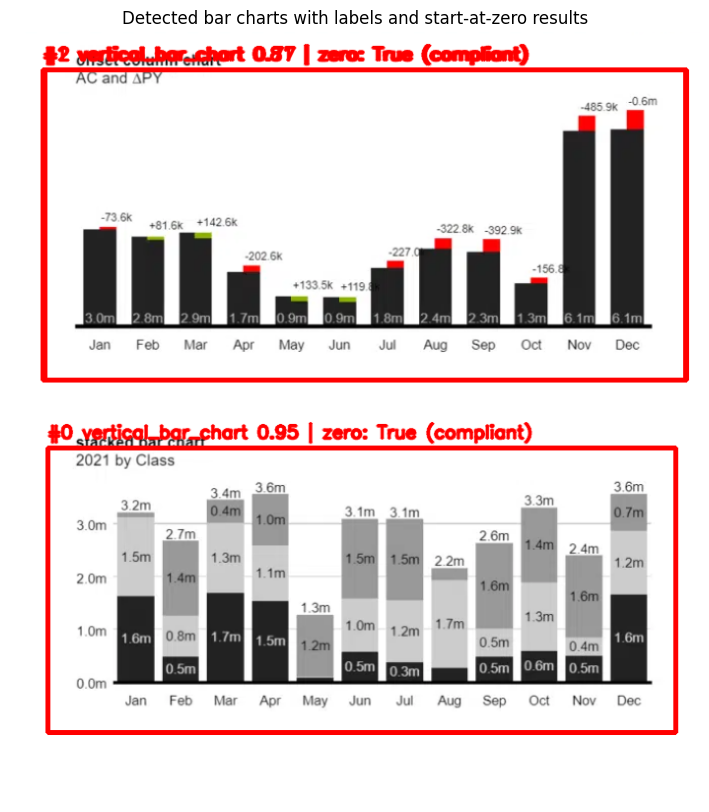

In [28]:
def draw_labeled_boxes(image_path, results):
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}\n"
            "Check IMAGE_PATH and make sure it points to the original dashboard image."
        )

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    for item in results:
        bbox = item["bbox_xyxy"]
        x1, y1, x2, y2 = bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]

        label = item.get("detector_label", "unknown")
        conf = item.get("detector_confidence", None)

        zero_result = item.get("start_at_zero_result", {})
        status = zero_result.get("status", "unknown")
        starts = zero_result.get("starts_at_zero", None)

        text = f"#{item['chart_id']} {label}"
        if conf is not None:
            text += f" {conf:.2f}"
        text += f" | zero: {starts} ({status})"

        # Draw box
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)

        # Draw label background
        text_y = max(y1 - 10, 20)
        cv2.putText(
            image_rgb,
            text,
            (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2,
            cv2.LINE_AA
        )

    plt.figure(figsize=(14, 10))
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title("Detected bar charts with labels and start-at-zero results")
    plt.show()

draw_labeled_boxes(IMAGE_PATH, results)

## Start-at-zero result table

In [29]:
rows = []

for item in results:
    zero = item.get("start_at_zero_result", {})

    rows.append({
        "chart_id": item.get("chart_id"),
        "detector_label": item.get("detector_label"),
        "detector_confidence": item.get("detector_confidence"),
        "orientation": item.get("orientation"),
        "bbox_x1": item.get("bbox_xyxy", {}).get("x1"),
        "bbox_y1": item.get("bbox_xyxy", {}).get("y1"),
        "bbox_x2": item.get("bbox_xyxy", {}).get("x2"),
        "bbox_y2": item.get("bbox_xyxy", {}).get("y2"),
        "status": zero.get("status"),
        "starts_at_zero": zero.get("starts_at_zero"),
        "axis_type": zero.get("axis_type"),
        "detected_axis_values": zero.get("detected_axis_values"),
        "zero_source": zero.get("zero_source"),
        "reason": zero.get("reason"),
        "crop_path": item.get("crop_path"),
    })

df = pd.DataFrame(rows)
df

,chart_id,detector_label,detector_confidence,orientation,bbox_x1,bbox_y1,bbox_x2,bbox_y2,status,starts_at_zero,axis_type,detected_axis_values,zero_source,reason,crop_path
0,0,vertical_bar_chart,0.945228,vertical,38,422,675,711,compliant,True,y-axis,"[0.0, 1.0, 2.0, 3.0]",axis_group,Zero found on value axis,crops/chart_0_vertical.png
1,1,vertical_bar_chart,0.812313,vertical,33,38,686,353,compliant,True,y-axis,[],None,No value-axis labels detected; treated as comp...,crops/chart_1_vertical.png
2,2,vertical_bar_chart,0.766921,vertical,35,38,685,353,compliant,True,y-axis,[],None,No value-axis labels detected; treated as comp...,crops/chart_2_vertical.png


## Show each cropped chart with its result

This works only if the crop files still exist in your project folder, for example `crops/chart_0_vertical.png`.

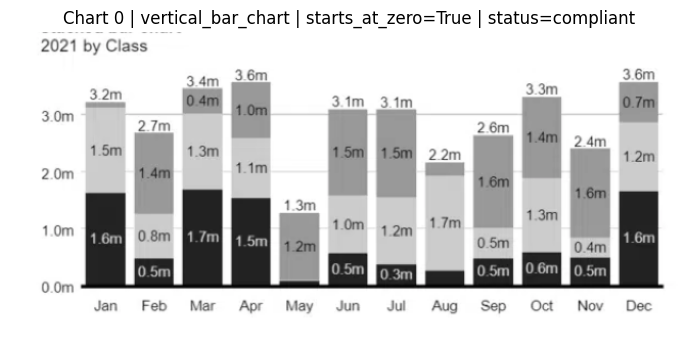

Detected axis values: [0.0, 1.0, 2.0, 3.0]
Reason: Zero found on value axis
--------------------------------------------------------------------------------


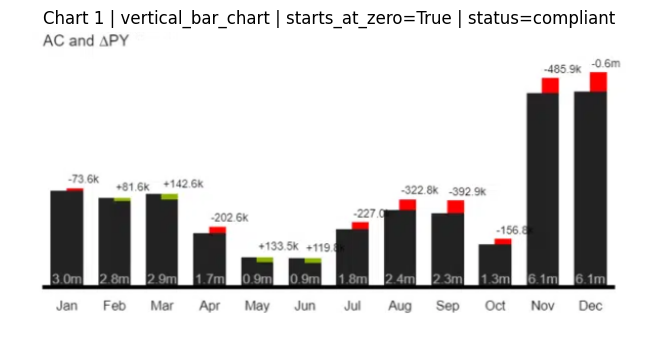

Detected axis values: []
Reason: No value-axis labels detected; treated as compliant by client rule
--------------------------------------------------------------------------------


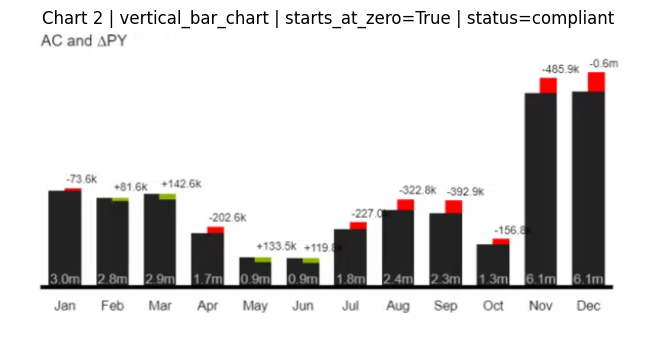

Detected axis values: []
Reason: No value-axis labels detected; treated as compliant by client rule
--------------------------------------------------------------------------------


In [30]:
def show_crops_with_results(results):
    for item in results:
        crop_path = item.get("crop_path")
        zero = item.get("start_at_zero_result", {})

        if not crop_path or not Path(crop_path).exists():
            print(f"Chart {item.get('chart_id')}: crop not found -> {crop_path}")
            continue

        img_bgr = cv2.imread(crop_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        title = (
            f"Chart {item.get('chart_id')} | {item.get('detector_label')} | "
            f"starts_at_zero={zero.get('starts_at_zero')} | status={zero.get('status')}"
        )

        plt.figure(figsize=(10, 4))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title(title)
        plt.show()

        print("Detected axis values:", zero.get("detected_axis_values"))
        print("Reason:", zero.get("reason"))
        print("-" * 80)

show_crops_with_results(results)

## Optional: save the labeled image

In [6]:
def save_labeled_image(image_path, results, output_path="labeled_output.png"):
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    for item in results:
        bbox = item["bbox_xyxy"]
        x1, y1, x2, y2 = bbox["x1"], bbox["y1"], bbox["x2"], bbox["y2"]

        label = item.get("detector_label", "unknown")
        zero = item.get("start_at_zero_result", {})
        status = zero.get("status", "unknown")
        starts = zero.get("starts_at_zero", None)

        text = f"#{item['chart_id']} {label} | zero={starts} | {status}"

        cv2.rectangle(image_bgr, (x1, y1), (x2, y2), (0, 0, 255), 3)
        cv2.putText(
            image_bgr,
            text,
            (x1, max(y1 - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 0, 255),
            2,
            cv2.LINE_AA
        )

    cv2.imwrite(output_path, image_bgr)
    print(f"Saved labeled image to: {output_path}")

# Uncomment to save:
# save_labeled_image(IMAGE_PATH, results, "labeled_output.png")